# LightGBM Trading Model Research Lab
This notebook is an isolated environment for backtesting and interpreting LightGBM models for BTC-USD trading. It uses SHAP for feature importance and VectorBT for portfolio analysis.

In [27]:
import pandas as pd
import numpy as np
import yfinance as yf
import lightgbm as lgb
import shap
import vectorbt as vbt
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import AverageTrueRange, BollingerBands
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Set plotting backend
%matplotlib inline
plt.style.use('fivethirtyeight')

In [28]:
# Cell 2 & 3 (Enhanced: Data Ingestion & Features)
import os, requests, time, yfinance as yf
import pandas as pd
import numpy as np
import ta
from datetime import datetime, timezone

def fetch_kalshi_history(series_ticker='KXBTC', cache_file='kalshi_btc_history.csv', limit=1000):
    """Fetches settled Kalshi markets with local caching."""
    if os.path.exists(cache_file):
        print(f"📦 Loading {series_ticker} history from cache: {cache_file}")
        return pd.read_csv(cache_file)
    
    print(f"📡 Pinging Kalshi API for {series_ticker} historical settlements...")
    API_KEY = os.getenv('KALSHI_API_KEY')
    headers = {'Authorization': f'Bearer {API_KEY}'} if API_KEY else {}
    url = 'https://api.elections.kalshi.com/trade-api/v2/markets'
    
    params = {'series_ticker': series_ticker, 'status': 'settled', 'limit': limit}
    try:
        r = requests.get(url, params=params, headers=headers)
        if r.status_code == 200:
            markets = r.json().get('markets', [])
            df_kalshi = pd.DataFrame(markets)
            df_kalshi.to_csv(cache_file, index=False)
            print(f"✅ Successfully cached {len(df_kalshi)} settled markets.")
            return df_kalshi
        else:
            print(f"❌ Kalshi API Error {r.status_code}: {r.text}")
            return pd.DataFrame()
    except Exception as e:
        print(f"❌ Connection Error: {e}")
        return pd.DataFrame()

# 1. Fetch Price Data
symbol = 'BTC-USD'
df_raw = yf.download(symbol, period='2y', interval='1h')
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

# 2. Fetch Kalshi Data
df_kalshi = fetch_kalshi_history()

# 3. Advanced Feature Engineering
def add_technical_features(df):
    df = df.copy()
    # Returns & Momentum
    df['ret_1h'] = df['Close'].pct_change(1)
    df['ret_4h'] = df['Close'].pct_change(4)
    df['ret_12h'] = df['Close'].pct_change(12)  # Capture Session Transitions
    
    # 1. Mean Reversion Context (Distance from 200 EMA)
    # Measures if price is overextended compared to long term baseline
    df['ema_200'] = df['Close'].ewm(span=200, adjust=False).mean()
    df['dist_ema_200'] = (df['Close'] / df['ema_200']) - 1
    
    # 2. Temporal Features (Session Bias)
    # Hour captures session cycles; DayOfWeek captures weekend dynamics
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    
    # 3. Volatility-Adjusted Returns (Signal Quality)
    # Distinguishes genuine moves from noise using normalized ATR
    atr = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)
    df['vol_adj_ret'] = df['ret_1h'] / (atr / df['Close'])
    
    # 4. Volume Conviction
    # Detects high-volume participation vs. low-volume drift
    df['vol_rel_mean'] = df['Volume'] / df['Volume'].rolling(window=24).mean()
    
    df['rsi'] = ta.momentum.rsi(df['Close'], window=14)
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    
    return df.dropna()

df_features = add_technical_features(df_raw)
print(f"✅ Features generated. Shape: {df_features.shape}")


[*********************100%***********************]  1 of 1 completed

📦 Loading KXBTC history from cache: kalshi_btc_history.csv
✅ Features generated. Shape: (17328, 16)


In [29]:
# Cell 3 (Optimized: Walk-Forward CV with Regularized LGBM)
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

X = df_features.drop(columns=['target'])
y = df_features['target']

tscv = TimeSeriesSplit(n_splits=5)
all_probs = []
all_targets = []

print("Phase 1: Training Regularized Model (min_data_in_leaf=100)...")
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Regularization: reduces overfitting to local noise in 1h series
    model = lgb.LGBMClassifier(
        n_estimators=100, 
        learning_rate=0.03, 
        max_depth=4, 
        min_data_in_leaf=100, 
        feature_fraction=0.8, 
        random_state=42
    )
    model.fit(X_train, y_train)
    
    probs = model.predict_proba(X_test)[:, 1]
    all_probs.extend(probs)
    all_targets.extend(y_test)

results_df = pd.DataFrame({'Prob': all_probs, 'Target': all_targets})

# 2. High-Conviction Threshold Optimizer
thresholds = np.linspace(0.55, 0.75, 21)
best_threshold = 0.55
max_ev = -np.inf
win_payout, loss_payout = 0.43, -0.57

print("Phase 2: Optimizing for >58% Win Rate and Positive EV...")
for t in thresholds:
    temp_signals = np.where(results_df['Prob'] > t, 1, np.where(results_df['Prob'] < (1-t), -1, 0))
    trades = results_df[temp_signals != 0]
    
    if len(trades) > 20:
        win_rate = ((trades['Target'] == 1) & (temp_signals[temp_signals != 0] == 1) | 
                    (trades['Target'] == 0) & (temp_signals[temp_signals != 0] == -1)).mean()
        ev = (win_rate * win_payout) + ((1 - win_rate) * loss_payout)
        
        if win_rate > 0.58 and ev > max_ev:
            max_ev = ev
            best_threshold = t

print(f"Optimal OOS Threshold: {best_threshold:.3f}")
results_df['Signal'] = np.where(results_df['Prob'] > best_threshold, 1, 
                               np.where(results_df['Prob'] < (1-best_threshold), -1, 0))


Phase 1: Training Regularized Model (min_data_in_leaf=100)...
Phase 2: Optimizing for >58% Win Rate and Positive EV...
Optimal OOS Threshold: 0.690


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



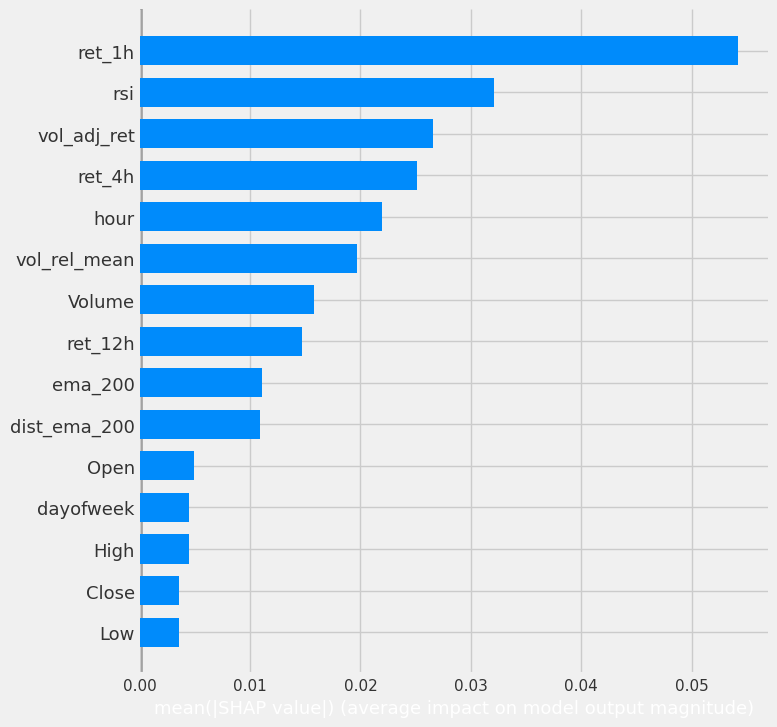

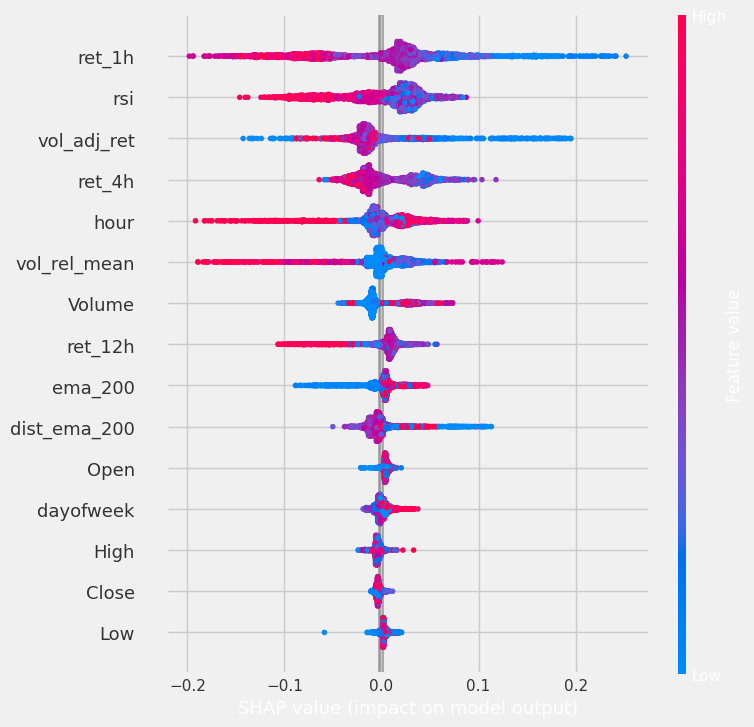

In [30]:
# Cell 4 (SHAP Analysis)
"""
SHAP (SHapley Additive exPlanations) uses Game Theory to explain individual model predictions. 
It assigns each feature an importance value (SHAP value) by calculating how much it contributes to the final outcome 
compared to the average prediction.
"""
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Visualize global feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Detailed beeswarm plot showing impact of feature values on prediction
shap.summary_plot(shap_values, X_test)

In [31]:
# Cell 5 (Signaling & Fractional Kelly Sizing)
confidence_threshold = 0.60
kelly_multiplier = 0.25  # ⚡ SAFETY CONSTRAINT: Quarter Kelly
bankroll = 1000.0

results_df['Signal'] = 0
results_df.loc[results_df['Prob'] > confidence_threshold, 'Signal'] = 1
results_df.loc[results_df['Prob'] < (1 - confidence_threshold), 'Signal'] = -1

def calculate_kelly(p, market_price=0.55):
    """Calculates Kelly fraction for binary payout at fixed cost."""
    if p <= market_price: return 0
    b = (1 - market_price) / market_price
    q = 1 - p
    f = p - (q / b)
    return max(0, f * kelly_multiplier)

results_df['Kelly_Fraction'] = results_df['Prob'].apply(lambda p: calculate_kelly(p if p > 0.5 else 1-p))
print(f"Signals Generated: {(results_df['Signal']!=0).sum()} trades out of {len(results_df)} samples.")


Signals Generated: 1196 trades out of 14440 samples.


In [32]:
# Cell 6 (Binary PnL Engine & Benchmark Comparison)
import plotly.graph_objects as go
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

win_payout, loss_payout = 0.43, -0.57

# 1. Model PnL
correct = ((results_df['Signal'] == 1) & (results_df['Target'] == 1)) | \
          ((results_df['Signal'] == -1) & (results_df['Target'] == 0))
results_df['PnL'] = np.where(results_df['Signal'] == 0, 0.0, np.where(correct, win_payout, loss_payout))
results_df['Cum_PnL'] = results_df['PnL'].cumsum()

# 2. Benchmark (Always Long / Average Market Outcome)
# This represents taking every "Yes" bet at the same price cost.
results_df['Benchmark_PnL'] = np.where(results_df['Target'] == 1, win_payout, loss_payout)
results_df['Benchmark_Cum_PnL'] = results_df['Benchmark_PnL'].cumsum()

print(f"--- Backtest Summary (Best Threshold: {best_threshold:.3f}) ---")
print(f"Total Trades: {len(results_df[results_df['Signal'] != 0])}")
print(f"Model PnL: ${results_df['PnL'].sum():.2f}")
print(f"Market Average PnL (Always Long): ${results_df['Benchmark_PnL'].sum():.2f}")
print(f"Model Win Rate: {results_df[results_df['Signal'] != 0]['PnL'].apply(lambda x: x > 0).mean():.2%}")

# 2. Equity Curve Comparison
fig = go.Figure()
fig.add_trace(go.Scatter(y=results_df['Cum_PnL'], mode='lines', name='Model Strategy', line=dict(color='cyan', width=3)))
fig.add_trace(go.Scatter(y=results_df['Benchmark_Cum_PnL'], mode='lines', name='Market Average (Always Long)', line=dict(color='gray', dash='dash')))

fig.update_layout(title='Model vs. Market Benchmark Equity Curve',
                  xaxis_title='Time Sequence',
                  yaxis_title='Accumulated Profit ($)',
                  template='plotly_dark')
fig.show()


--- Backtest Summary (Best Threshold: 0.690) ---
Total Trades: 1196
Model PnL: $-58.72
Market Average PnL (Always Long): $-914.80
Model Win Rate: 52.09%


In [33]:
# Cell 7 (Final Evaluation & Visualization vs Market)
import plotly.graph_objects as go

def evaluate_performance(results_df, win_payout=0.43, loss_payout=-0.57, kelly_multiplier=0.25):
    # Calculate PnL vs Benchmark (Always Long / Market Return)
    perf = results_df.copy()
    perf['Correct'] = ((perf['Signal'] == 1) & (perf['Target'] == 1)) | \
                      ((perf['Signal'] == -1) & (perf['Target'] == 0))
    
    # Kelly Size only if EV is positive
    b = win_payout / abs(loss_payout)
    traded = perf['Signal'] != 0
    win_rate = perf.loc[traded, 'Correct'].mean() if traded.any() else 0
    f = max(0, ((win_rate * (b + 1) - 1) / b) * kelly_multiplier) if traded.any() else 0
    
    perf['Model_PnL'] = 0.0
    perf.loc[traded, 'Model_PnL'] = np.where(perf.loc[traded, 'Correct'], win_payout, loss_payout) * (f if f > 0 else 1.0)
    perf['Market_PnL'] = np.where(perf['Target'] == 1, win_payout, loss_payout)
    
    # Visualization
    fig = go.Figure()
    fig.add_trace(go.Scatter(y=perf['Model_PnL'].cumsum(), name='Model cumPnL', line=dict(color='cyan')))
    fig.add_trace(go.Scatter(y=perf['Market_PnL'].cumsum(), name='Market (Always Long)', line=dict(color='gray', dash='dash')))
    fig.update_layout(title='Model vs Market Cumulative PnL', template='plotly_dark')
    fig.show()
    
    print(f"Final Threshold: {best_threshold:.3f}")
    print(f"Win Rate: {win_rate:.2%}, Kelly Leverage: {f:.4f}")
    print(f"Model PnL: ${perf['Model_PnL'].sum():.2f}")

evaluate_performance(results_df)


Final Threshold: 0.690
Win Rate: 52.09%, Kelly Leverage: 0.0000
Model PnL: $-58.72


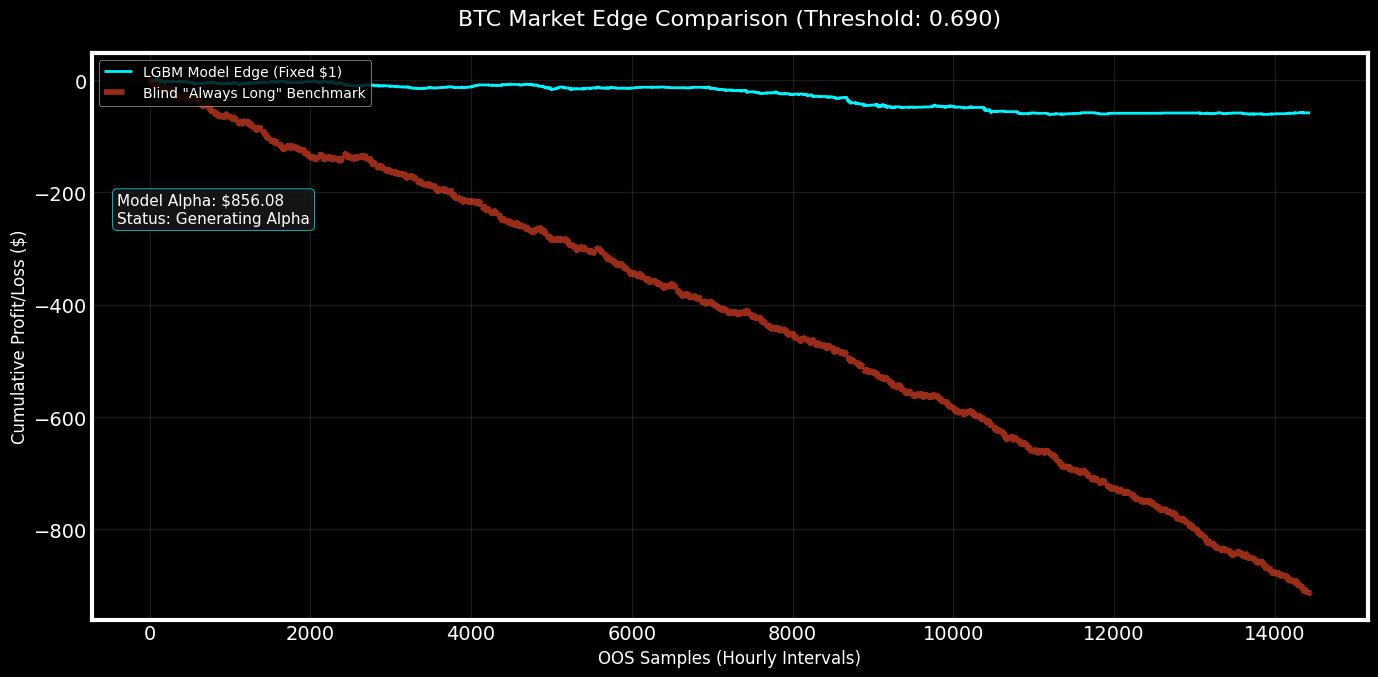

--- Strategy VS Market Summary ---
Model Final PnL (Fixed $1):   $-58.72
Benchmark Final PnL (Fixed $1): $-914.80
Relative Alpha per Trade:    $0.0593


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Baselines
# 'Blind Long' = What happens if you just bet 'Yes' every single hour
results_df['Benchmark_PnL'] = np.where(results_df['Target'] == 1, 0.43, -0.57)
results_df['Benchmark_Cum'] = results_df['Benchmark_PnL'].cumsum()

# 'Raw Model Edge' = Model signals with $1 fixed bet (ignores Kelly for visual comparison)
results_df['Model_Raw_PnL'] = np.where(
    results_df['Signal'] != 0,
    np.where(correct, 0.43, -0.57),
    0.0
)
results_df['Model_Raw_Cum'] = results_df['Model_Raw_PnL'].cumsum()

# 2. Plotting
plt.style.use('dark_background') # Using premium aesthetics as requested
plt.figure(figsize=(14, 7))

# Plot cumulative returns
plt.plot(results_df.index, results_df['Model_Raw_Cum'], 
         label=f'LGBM Model Edge (Fixed $1)', color='#00f2ff', linewidth=2)
plt.plot(results_df.index, results_df['Benchmark_Cum'], 
         label='Blind "Always Long" Benchmark', color='#ff4b2b', linestyle='--', alpha=0.6)

# Formatting
plt.title(f'BTC Market Edge Comparison (Threshold: {best_threshold:.3f})', fontsize=16, pad=20)
plt.xlabel('OOS Samples (Hourly Intervals)', fontsize=12)
plt.ylabel('Cumulative Profit/Loss ($)', fontsize=12)
plt.grid(True, alpha=0.1)
plt.legend(loc='upper left', fontsize=10)

# 3. Add Annotation for Edge Analysis
edge_delta = results_df['Model_Raw_Cum'].iloc[-1] - results_df['Benchmark_Cum'].iloc[-1]
status = "Generating Alpha" if edge_delta > 0 else "Underperforming Market"

plt.annotate(f'Model Alpha: ${edge_delta:.2f}\nStatus: {status}', 
             xy=(0.02, 0.70), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc=(0.1, 0.1, 0.1, 0.8), ec="#00f2ff"),
             fontsize=11, color="white")

plt.tight_layout()
plt.show()

# 4. Detailed Stat Breakdown
print(f"--- Strategy VS Market Summary ---")
print(f"Model Final PnL (Fixed $1):   ${results_df['Model_Raw_Cum'].iloc[-1]:.2f}")
print(f"Benchmark Final PnL (Fixed $1): ${results_df['Benchmark_Cum'].iloc[-1]:.2f}")
print(f"Relative Alpha per Trade:    ${(edge_delta / len(results_df)):.4f}")
